In [1]:
%pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import time
import numpy as np
import torch as tc
import matplotlib.pyplot as plt

In [3]:
tc.cuda.is_available()

True

In [4]:
os.cpu_count()

4

In [5]:
from torchvision import datasets, transforms

mean = tc.Tensor([0.485, 0.456, 0.406])
std = tc.Tensor([0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
])

train_dataset = datasets.ImageFolder(root='/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train', transform=train_transform)
test_dataset = datasets.ImageFolder(root='/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test', transform=test_transform)

In [6]:
print("Number of training samples:", len(train_dataset))
print("Number of testing samples:", len(test_dataset))

Number of training samples: 9605
Number of testing samples: 1000


In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=16, num_workers=4)

In [8]:
def imshow(img):
    img = img * std.unsqueeze(1).unsqueeze(2) + mean.unsqueeze(1).unsqueeze(2)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

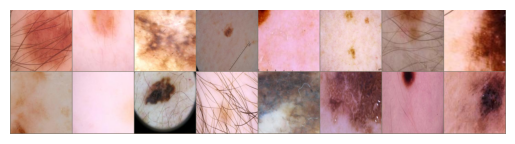

benign, benign, malignant, malignant, malignant, benign, benign, malignant, malignant, benign, malignant, benign, malignant, malignant, benign, malignant


In [9]:
from torchvision.utils import make_grid

images, labels = next(iter(train_loader))
imshow(make_grid(images))
print(', '.join(f'{train_loader.dataset.classes[labels[i]]}' for i in range(len(labels))))

In [10]:
from torchvision import models
from torchsummary import summary

model = models.resnet18(weights='ResNet18_Weights.IMAGENET1K_V1')
model = model.cuda()
summary(model, (3, 224, 224))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 74.6MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [11]:
for index, (name, param) in enumerate(model.named_parameters()):
    print(f"Index: {index}, Name: {name}, Requires Grad: {param.requires_grad}")

Index: 0, Name: conv1.weight, Requires Grad: True
Index: 1, Name: bn1.weight, Requires Grad: True
Index: 2, Name: bn1.bias, Requires Grad: True
Index: 3, Name: layer1.0.conv1.weight, Requires Grad: True
Index: 4, Name: layer1.0.bn1.weight, Requires Grad: True
Index: 5, Name: layer1.0.bn1.bias, Requires Grad: True
Index: 6, Name: layer1.0.conv2.weight, Requires Grad: True
Index: 7, Name: layer1.0.bn2.weight, Requires Grad: True
Index: 8, Name: layer1.0.bn2.bias, Requires Grad: True
Index: 9, Name: layer1.1.conv1.weight, Requires Grad: True
Index: 10, Name: layer1.1.bn1.weight, Requires Grad: True
Index: 11, Name: layer1.1.bn1.bias, Requires Grad: True
Index: 12, Name: layer1.1.conv2.weight, Requires Grad: True
Index: 13, Name: layer1.1.bn2.weight, Requires Grad: True
Index: 14, Name: layer1.1.bn2.bias, Requires Grad: True
Index: 15, Name: layer2.0.conv1.weight, Requires Grad: True
Index: 16, Name: layer2.0.bn1.weight, Requires Grad: True
Index: 17, Name: layer2.0.bn1.bias, Requires Grad

In [12]:
for index, (name, param) in enumerate(model.named_parameters()):
    if index < 39 or 'bn' in name:
        param.requires_grad = False

In [13]:
for index, (name, param) in enumerate(model.named_parameters()):
    print(f"Index: {index}, Name: {name}, Requires Grad: {param.requires_grad}")

Index: 0, Name: conv1.weight, Requires Grad: False
Index: 1, Name: bn1.weight, Requires Grad: False
Index: 2, Name: bn1.bias, Requires Grad: False
Index: 3, Name: layer1.0.conv1.weight, Requires Grad: False
Index: 4, Name: layer1.0.bn1.weight, Requires Grad: False
Index: 5, Name: layer1.0.bn1.bias, Requires Grad: False
Index: 6, Name: layer1.0.conv2.weight, Requires Grad: False
Index: 7, Name: layer1.0.bn2.weight, Requires Grad: False
Index: 8, Name: layer1.0.bn2.bias, Requires Grad: False
Index: 9, Name: layer1.1.conv1.weight, Requires Grad: False
Index: 10, Name: layer1.1.bn1.weight, Requires Grad: False
Index: 11, Name: layer1.1.bn1.bias, Requires Grad: False
Index: 12, Name: layer1.1.conv2.weight, Requires Grad: False
Index: 13, Name: layer1.1.bn2.weight, Requires Grad: False
Index: 14, Name: layer1.1.bn2.bias, Requires Grad: False
Index: 15, Name: layer2.0.conv1.weight, Requires Grad: False
Index: 16, Name: layer2.0.bn1.weight, Requires Grad: False
Index: 17, Name: layer2.0.bn1.bi

In [14]:
import torch.nn as nn
import torch.nn.init as init

model.fc = nn.Linear(model.fc.in_features, 1)
init.xavier_normal_(model.fc.weight)
model = model.cuda()
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [15]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.RAdam(filter(lambda param: param.requires_grad, model.parameters()), lr=5e-3, weight_decay=5e-6, decoupled_weight_decay=True, foreach=True)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [16]:
num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    epoch_train_loss = 0
    epoch_val_loss = 0
    epoch_train_corrects = 0
    epoch_val_corrects = 0

    model.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.cuda(), targets.cuda()
        targets = targets.unsqueeze(-1).float()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        probs = tc.sigmoid(outputs)
        preds = (probs >= 0.5).int()
        
        loss = criterion(outputs, targets)
        epoch_train_loss += loss.item() * inputs.size(0)
        epoch_train_corrects += tc.sum(preds == targets.data).float()

        loss.backward()
        optimizer.step()

    scheduler.step()

    epoch_train_loss /= len(train_dataset)
    epoch_train_accuracy = epoch_train_corrects / len(train_dataset)
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy.cpu())

    model.eval()
    with tc.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.cuda(), targets.cuda()
            targets = targets.unsqueeze(-1).float()
            
            val_outputs = model(inputs)
            
            val_probs = tc.sigmoid(val_outputs)
            val_preds = (val_probs >= 0.5).int()
            
            val_loss = criterion(val_outputs, targets)
            epoch_val_loss += val_loss.item() * inputs.size(0)
            epoch_val_corrects += tc.sum(val_preds == targets.data).float()

    epoch_val_loss /= len(test_dataset)
    epoch_val_accuracy = epoch_val_corrects / len(test_dataset)
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy.cpu())

    print("Epoch {}/{}: Train Loss = {:.4f}, Val Loss = {:.4f}, Train Acc = {:.4f}, Val Acc = {:.4f}".format(
        epoch + 1, num_epochs, train_losses[-1], val_losses[-1], train_accuracies[-1], val_accuracies[-1]))

end_time = time.time()
training_time = end_time - start_time

print("Training time: {:.2f}s".format(training_time))

Epoch 1/20: Train Loss = 0.3552, Val Loss = 0.2583, Train Acc = 0.8585, Val Acc = 0.8960
Epoch 2/20: Train Loss = 0.2996, Val Loss = 0.2270, Train Acc = 0.8792, Val Acc = 0.9130
Epoch 3/20: Train Loss = 0.2778, Val Loss = 0.2299, Train Acc = 0.8911, Val Acc = 0.9040
Epoch 4/20: Train Loss = 0.2757, Val Loss = 0.2260, Train Acc = 0.8956, Val Acc = 0.9020
Epoch 5/20: Train Loss = 0.2520, Val Loss = 0.2144, Train Acc = 0.9043, Val Acc = 0.9150
Epoch 6/20: Train Loss = 0.2540, Val Loss = 0.2266, Train Acc = 0.9014, Val Acc = 0.9160
Epoch 7/20: Train Loss = 0.2307, Val Loss = 0.2175, Train Acc = 0.9092, Val Acc = 0.9140
Epoch 8/20: Train Loss = 0.2186, Val Loss = 0.1862, Train Acc = 0.9114, Val Acc = 0.9190
Epoch 9/20: Train Loss = 0.2201, Val Loss = 0.2278, Train Acc = 0.9155, Val Acc = 0.9190
Epoch 10/20: Train Loss = 0.2318, Val Loss = 0.2180, Train Acc = 0.9106, Val Acc = 0.9170
Epoch 11/20: Train Loss = 0.2103, Val Loss = 0.2007, Train Acc = 0.9150, Val Acc = 0.9170
Epoch 12/20: Train 

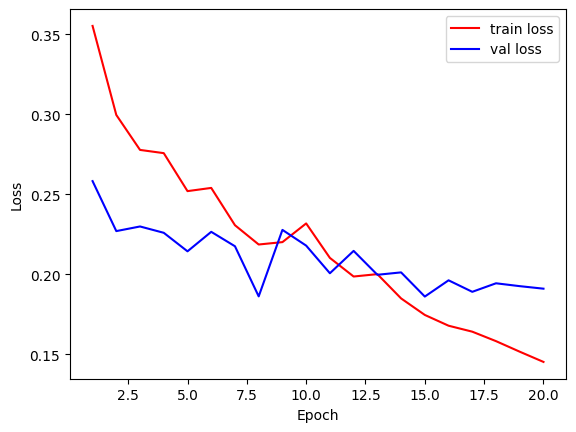

In [17]:
plt.plot(range(1, num_epochs + 1), train_losses, color="red", label="train loss")
plt.plot(range(1, num_epochs + 1), val_losses, color="blue", label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

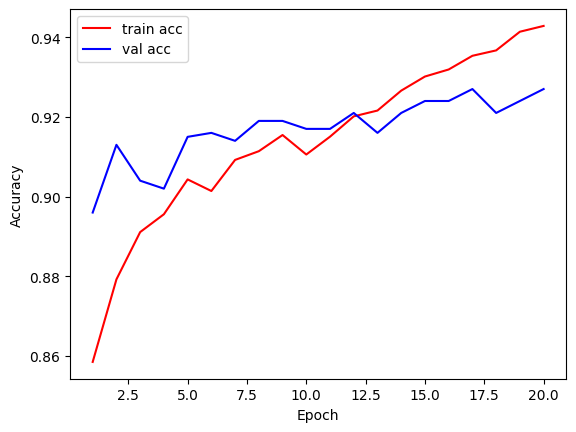

In [18]:
plt.plot(range(1, num_epochs + 1), train_accuracies, color="red", label="train acc")
plt.plot(range(1, num_epochs + 1), val_accuracies, color="blue", label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [19]:
y_test = []
y_pred = []

model.eval()

with tc.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.cuda()
        outputs = model(inputs)
        probs = tc.sigmoid(outputs)
        preds = (probs >= 0.5).int()
        y_test.append(targets)
        y_pred.append(preds)

y_test = tc.cat(y_test).cpu()
y_pred = tc.cat(y_pred).cpu()

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy score: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision score: {:.4f}".format(precision_score(y_test, y_pred, average='weighted')))
print("Recall score: {:.4f}".format(recall_score(y_test, y_pred, average='weighted')))
print("F1 score: {:.4f}".format(f1_score(y_test, y_pred, average='weighted')))

Accuracy score: 0.9270
Precision score: 0.9286
Recall score: 0.9270
F1 score: 0.9269


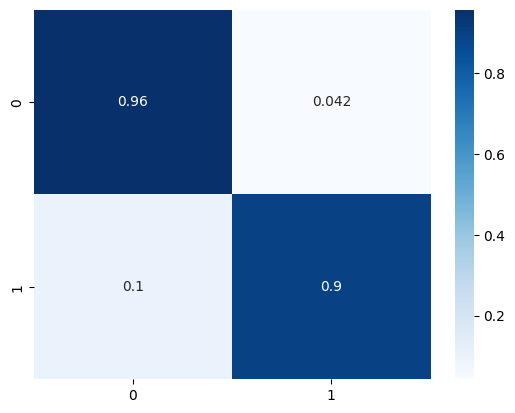

In [21]:
import seaborn as sb
from sklearn.metrics import confusion_matrix

cfm = confusion_matrix(y_test, y_pred)

sb.heatmap(cfm / np.sum(cfm, axis=1), annot=True, fmt=".2", cmap="Blues")
plt.show()

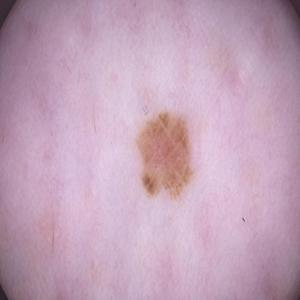

In [22]:
from PIL import Image

image = Image.open('/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign/melanoma_10000.jpg')
image

In [23]:
image = test_transform(image).unsqueeze(0)
image = image.cuda()

with tc.no_grad():
    output = model(image)
    prob = tc.sigmoid(output)
    pred = (prob >= 0.5).int()
    
print('The predicted skin cancer is', test_loader.dataset.classes[pred])

The predicted skin cancer is benign


In [24]:
tc.save(model, 'model.pth')